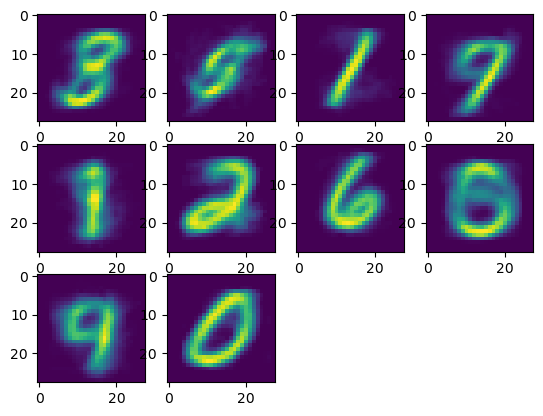

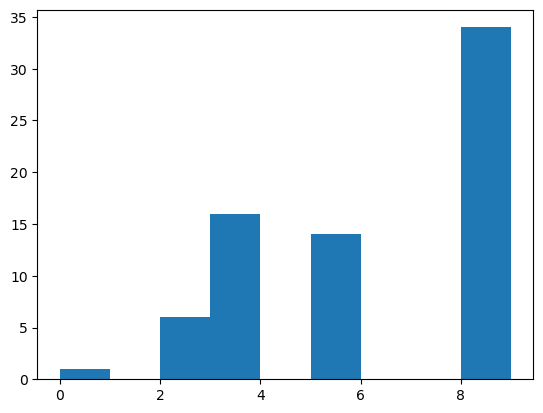

In [2]:
'''
Sample solution for Lab5 COMP3055 UNNC
Environments:   Python = 3.7.4
                                numpy = 1.19.1
                                scikit-learn = 0.21.3
                                matplotlib = 3.1.1
'''

import numpy as np
from sklearn.datasets import fetch_openml

'''
fetch data using fetch_openml() and save locally. Once saved, this code snippet can be commented
'''

X, y = fetch_openml('mnist_784', data_home='./', return_X_y=True)  # fetch data using fetch_openml function
X = X / 255.  # Normalization
X = X.values  # Extract X values (from DataFrame to Numpy array)
y = y.values  # Extract Y values (from DataFrame to Numpy array)
X_train, X_test = X[:60000], X[60000:]  # Train Test split for X
y_train, y_test = y[:60000], y[60000:]  # Train Test split for Y
# Save fetched data in file 'mnist.npz' in the pickled format with keys x_train, y_train, x_test, y_test
np.savez('mnist.npz', x_train=X_train, y_train=y_train, x_test=X_test, y_test=y_test, allow_pickle=True)

'''
load data from local file
'''
data = np.load('mnist.npz', allow_pickle=True)  # load from 'mnist.npz'
x_train, y_train, x_test, y_test = \
    data['x_train'], data['y_train'], data['x_test'], data['y_test']  # using keys to extract variables

X_small = np.reshape(x_train[0:1000], (1000, 784))  # define a small set of training data
Y_small = np.array(y_train[0:1000], dtype=int)  # define a small set of training label in the data type of int
X_test = np.reshape(x_test[0:1000], (1000, 784))  # define a small set of testing data
Y_test = np.array(y_test[0:1000], dtype=int)  # define a small set of testing label in the data type of int

'''
apply k-means and visualize clusters' center
'''
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=10, init='k-means++').fit(X_small)  # define a KMeans and train with the small training set
kmeans.labels_ = Y_small  # assign values to kmeans.labels_
centers = np.reshape(kmeans.cluster_centers_, (10, 28, 28))  # extract the trained 10 cluster centers and reshape to the image size for visualization

plt.figure()  # define a figure
# display images with for loop
for i in range(10):
    plt.subplot(3, 4, i + 1)
    plt.imshow(centers[i])
plt.savefig("cluster_centers.png")  # save the figure to 'cluster_centers.png
plt.show()  # display the figure

'''
visualize label histogram of one cluster
'''
y_cluster = kmeans.predict(X_test)      # prediction on testing data
y_cluster1 = []         # define an empty list y_cluster1
# iterate through the prediction and add the index of predictions belongs to first cluster to y_cluster1
for i in range(1000):
    if y_cluster[i] == 0:
        y_cluster1.append(Y_test[i])

plt.hist(y_cluster1, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])    # plot histogram of the ground truth label for predictions belongs to first cluster
plt.savefig("label_histogram_of_one_cluster.png")       # save the figure to 'label_histogram_of_one_cluster.png
plt.show()              # display the figure